## Oppgave 1: Lag grunnleggende geometrier (*5 poeng*)

I denne oppgaven skal du lage skreddersydde funksjoner for å lage geometrier. Vi starter med en veldig enkel funksjon, og går videre til å lage funksjoner som kan håndtere ugyldige inngangsverdier.


**1a**: Lag en funksjon kalt `create_point_geom()` som har to parametere (x_coord, y_coord). Funksjonen skal lage et shapely "Point" geometriobjekt og returnere det.


In [118]:
from shapely import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon

In [119]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def create_point_geom(x_coord, y_coord):
    """ 
    Returnerer et Shapely Point-objekt fra x- og y-koordinater.
    """
    return Point(x_coord, y_coord)

Test funksjonen din ved å kjøre disse kodecellene:

In [120]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
# Demonstrere bruken av funksjonen
point1 = create_point_geom(0.0, 1.1)
print(point1)
print(point1.geom_type)

POINT (0 1.1)
Point


**1b**: Lag en funksjon kalt **`create_line_geom()`** som tar en liste over Shapely Point-objekter som parameter kalt **`points`** og returnerer et LineString-objekt av disse inputpunktene. I tillegg bør du passe på at funksjonen brukes som den skal:

- Inne i funksjonen bør du først sjekke med `assert` -funksjonaliteten at inputen er en **liste** . Hvis noe annet enn en liste sendes til funksjonen, skal du returnere en feilmelding: `"Input skal være en liste"`
- Du bør også sjekke med `assert` at inputlisten inneholder **minst** to verdier. Hvis ikke, returner en feilmelding: `"LineString-objekt krever minst to punkt!"`
- Valgfritt: Til slutt bør du sjekke med `assert` at alle verdiene i inputlisten er ekte Shapely Points. Hvis ikke, returner en feilmelding: `"Alle listeverdier skal være Shapely Point-objekter!"`


In [121]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def create_line_geom(points):
    """
    Returnerer et Shapely LineString-objekt fra en liste med Shapely Point-objekter.
    """
    assert type(points) == list, "Input skal være en liste"
    assert len(points) >= 2, "LineString-objekt krever minst to punkt!"
    assert all(isinstance(i, Point) for i in points), "Alle listeverdier skal være Shapely Point-objekter!"
    return LineString(points) 

Demonstrer bruken av funksjonen din; Lag for eksempel et linjeobjekt med to punkter: `Point(45.2, 22.34)` & `Point(100.22, -3.20)` og lagre resultatet i en variabel kalt `line1`:

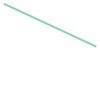

In [144]:
line1 = create_line_geom([Point(45.2, 22.34), Point(100.22, -3.20)])
line1

Kjør disse kodecellene for å sjekke løsningen din:

In [145]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
print(line1)
print(type(line1))

LINESTRING (45.2 22.34, 100.22 -3.2)
<class 'shapely.geometry.linestring.LineString'>


Sjekk om funksjonen din kontrollerer inputen riktig ved å kjøre denne kodecellen:

In [146]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
try:
    # Pass på noe annet enn en liste
    create_line_geom("Gi meg en linje")
except AssertionError:
    print("Fant en assertion-error. Listetesten fungerer.")
except Exception as e:
    raise e

Fant en assertion-error. Listetesten fungerer.


**1c**: Lag en funksjon kalt **`create_poly_geom()`** som har én parameter kalt **`coords`**. `coords`-parameteren skal inneholde **en liste med koordinattupler**. Funksjonen skal opprette og returnere et polygonobjekt basert på disse koordinatene.

- Inne i funksjonen bør du først sjekke med `assert` -functionality at inputen er en **liste**. Hvis noe annet enn en liste sendes for funksjonen, skal du returnere en feilmelding: `"Input skal være en liste"`
- Du bør også sjekke med `assert` at inputlisten inneholder **minst** tre verdier. Hvis ikke, returner en feilmelding: `"Polygon-objekt krever minst tre punkter!"`
- Sjekk datatypen til objektene i inputlisten. Alle verdier i inputlisten skal være tupler. Hvis ikke, returner en feilmelding: `"Alle listeverdier skal være koordinattupler!"` ved bruk av `assert`.
- **Valgfritt:** Tillat også en input som inneholder en liste med Shapely Point-objekter. Hvis `coords` inneholder en liste med Shapely Point-objekter, returner et polygon basert på disse punktene. Hvis inputen verken er en liste med tupler, eller en liste med punkter, returner en passende feilmelding ved å bruke `assert`.


In [147]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def create_poly_geom(coords):
    """
    Returnerer et Shapely Polygon-objekt fra en liste med enten koordinattupler eller Shapely Point-objekter. 
    """
    assert type(coords) == list, "Input skal være en liste"
    assert len(coords) >= 3, "Polygon-objekt krever minst tre punkter!"
    assert all(isinstance(i, tuple) for i in coords) or all(isinstance(i, Point) for i in coords), "Alle listeverdier må være enten koordinattupler eller Shapely Point-objekter."
    return Polygon(coords)

Demonstrer bruken av funksjonen. Lag for eksempel et polygon med tre punkter: `(45.2, 22.34)`, `(100.22, -3.20)` og `(70.0, 10.20)`.

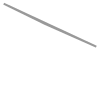

In [148]:
poly1 = create_poly_geom([(45.2, 22.34), (100.22, -3.20), (70.0, 10.20)])
poly1

In [149]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
print(poly1)
print(type(poly1))

POLYGON ((45.2 22.34, 100.22 -3.2, 70 10.2, 45.2 22.34))
<class 'shapely.geometry.polygon.Polygon'>


Sjekk om funksjonen din kontrollerer lengden på inputen riktig ved å kjøre denne kodecellen:

In [150]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
try:
    # Pass på noe annet enn en liste
    create_poly_geom("Lag et polygon")
except AssertionError:
    print("Listetesten fungerer")
except Exception as e:
    raise e

Listetesten fungerer


Det var det. Nå er du klar til å fortsette med oppgave 2.

## Oppgave 2: Attributter til geometrier (*5 poeng*)

**2a**: Lag en funksjon kalt `get_centroid()` som har én parameter kalt `geom`. Funksjonen bør ta en hvilken som helst form for Shapely-objekt som input, og returnere et midtpunkt av den geometrien. I tillegg bør du passe på at funksjonen brukes som den skal:

- Inne i funksjonen bør du først sjekke med `assert` -funksjonalitet at inputen er en Shapely Point, LineString eller Polygon geometri. Hvis noe annet enn et Shapely objekt sendes for funksjonen, bør du returnere en feilmelding: `"Input skal være en Shapely geometri!"`


In [151]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def get_centroid(geom):
    """
    Returnerer midtpunktet til en hvilken som helst form for Shapely-objekt. 
    """
    assert isinstance(geom, (Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon)), "Input skal være en Shapely geometri!"
    return geom.centroid

Test og demonstrer bruken av funksjonen. Du kan for eksempel lage shapely-objekter ved å bruke funksjonene du opprettet i oppgave 1 og skrive ut informasjon om midtpunktene deres:


In [156]:
square = create_poly_geom([(10, -10), (-10, -10), (-10, 10), (10, 10)])
square_centroid = get_centroid(square)
print(square_centroid)

POINT (0 0)


In [157]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
centroid = get_centroid(poly1)
print(centroid)

POINT (71.80666666666667 9.780000000000001)


Sjekk at assert-feilen fungerer som den skal:

In [158]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
try:
    # Bestå noe annet enn en Shapely geometri
    get_centroid("Gi meg en centroide.!")
except AssertionError:
    print("Fant en assertion-error. Geometri-testen virker.")
except Exception as e:
    raise e

Fant en assertion-error. Geometri-testen virker.


**2b**: Lag en funksjon kalt `get_area()` med én parameter kalt `polygon`. Funksjonen skal ta et Shapely Polygon-objekt som input og returnerer arealet til den geometrien.

- Inne i funksjonen bør du først sjekke med `assert` -funksjonalitet at inputen er en Shapely Polygon-geometri. Hvis noe annet enn en liste sendes for funksjonen, bør du returnere en feilmelding: `"Input skal være et Shapely Polygon-objekt!"`

In [159]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def get_area(polygon):
    """
    Returnerer arealet til et Shapely Polygon-objekt. 
    """
    assert type(polygon) == Polygon, "Input skal være et Shapely Polygon-objekt!"
    return polygon.area

Test og demonstrer bruken av funksjonen:

In [160]:
square = create_poly_geom([(10, -10), (-10, -10), (-10, 10), (10, 10)])
square_area = get_area(square)

print(f"Arealet til square er {square_area:.2f} enheter")

Arealet til square er 400.00 enheter


In [161]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
area = get_area(poly1)
print(round(area, 2))

17.28


Sjekk at assert-feilen fungerer:

In [162]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
try:
    # Bestå noe annet enn en Shapely geometri
    get_area("Gi meg et areal!")
except AssertionError:
    print("Geometri-testen virker")
except Exception as e:
    raise e

Geometri-testen virker


**2c**: Opprett en funksjon kalt `get_length()` med parameter kalt `geom`. Funksjonen skal akseptere enten et Shapely LineString eller Polygon-objekt som input. Funksjonen skal sjekke typen inndata og returnerer lengden på linjen hvis input er LineString og lengden på den ytre ringen hvis input er Polygon. Hvis noe annet sendes til funksjonen, bør du returnere en `Error` `"'geom' skal være enten LineString eller Polygon!"`. (Bruk assert-funksjonalitet).


In [163]:
# SKRIV DIN KODE HER OG FJERN LINJEN "raise NotImplementedError()"

def get_length(geom):
    """
    Returnerer lengden til et Shapely LineString-objekt og lengden på den ytre ringen til et Shapely Polygon-objekt. 
    """
    assert isinstance(geom, (LineString, Polygon)), "'geom' skal være enten LineString eller Polygon!"
    return geom.length if isinstance(geom, LineString) else geom.exterior.length 

Test og demonstrer bruken av funksjonen:

In [164]:
line2 = create_line_geom([Point(33.66, 23.95), Point(94.04, -78.67)])
poly2 = create_poly_geom([(10, -10), (-10, -10), (-10, 10), (10, 10)])

line2_length = get_length(line2)
poly2_length = get_length(poly2)

print(f"Lengden til line2 er {line2_length:.2f} enheter.")
print(f"Omkretsen til poly2 er {poly2_length:.2f} enheter.")

Lengden til line2 er 119.07 enheter.
Omkretsen til poly2 er 80.00 enheter.


In [165]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
line_length = get_length(line1)
print("Linjelengde:", round(line_length,2))

Linjelengde: 60.66


In [166]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
poly_exterior_length = get_length(poly1)
print("Polygon omkrets:", round(poly_exterior_length,2))

Polygon omkrets: 121.33


In [167]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!
try:
    # Send noe annet enn en Shapely LineString eller Polygon
    get_length(Point(1,2))
except AssertionError:
    print("Geometri-testen virker")
except Exception as e:
    raise e

Geometri-testen virker


## Docstrings

Har du lagt til en docstring til alle funksjonene du definerte? Hvis ikke, legg dem til nå :) En kort en-linjes docstring er nok i denne øvelsen.

Sjekk: inneholder alle funksjonene dine en docstring? 1 poeng tildeles automatisk dersom testen under består.

I tillegg kan du kjøre kodecellen nedenfor for å sjekke alle docstringene!

In [168]:
# TEST-CELLE
## Ikke slett denne cellen, og nye kodeceller du lager til denne deloppgaven skal komme før denne!

# List opp alle funksjonene vi har laget
functions = [create_point_geom, create_line_geom, create_poly_geom, 
             get_centroid, get_area, get_length]

print("Mine funksjoner:\n")

for function in functions:
    # Skriv ut funksjonsnavn og docstring:
    print("-", function.__name__ +":", function.__doc__)

Mine funksjoner:

- create_point_geom:  
    Returnerer et Shapely Point-objekt fra x- og y-koordinater.
    
- create_line_geom: 
    Returnerer et Shapely LineString-objekt fra en liste med Shapely Point-objekter.
    
- create_poly_geom: 
    Returnerer et Shapely Polygon-objekt fra en liste med enten koordinattupler eller Shapely Point-objekter. 
    
- get_centroid: 
    Returnerer midtpunktet til en hvilken som helst form for Shapely-objekt. 
    
- get_area: 
    Returnerer arealet til et Shapely Polygon-objekt. 
    
- get_length: 
    Returnerer lengden til et Shapely LineString-objekt og lengden på den ytre ringen til et Shapely Polygon-objekt. 
    


## Ferdig!